# Параметризованные эксперименты: модель M/M/c

Исследование влияния параметров (λ, μ, c) на характеристики
системы массового обслуживания: время ожидания, вероятность
ожидания, сравнение с аналитическими формулами.

In [1]:
using DrWatson
@quickactivate "project"
using StableRNGs
using Distributions
using ConcurrentSim
using ResumableFunctions
using DataFrames
using Statistics
using CSV
using Plots
using Random

## Наборы параметров для экспериментов

In [2]:
param_sets = [
    (lam = 0.5, mu = 0.5, c = 1, label = "M/M/1, ρ=1.0"),
    (lam = 0.5, mu = 0.5, c = 2, label = "M/M/2, ρ=0.5"),
    (lam = 0.9, mu = 0.5, c = 2, label = "M/M/2, ρ=0.9"),
    (lam = 0.9, mu = 0.5, c = 3, label = "M/M/3, ρ=0.6"),
    (lam = 1.5, mu = 0.5, c = 4, label = "M/M/4, ρ=0.75"),
]

NUM_CUSTOMERS = 500
SEED = 123

123

## Формула Эрланга C (вероятность задержки)

In [3]:
function analytical_Pwait(lam, mu, c)
    rho = lam / (c * mu)
    if rho >= 1
        return NaN
    end
    sum_term = sum(((c * rho)^n / factorial(n)) for n = 0:(c-1))
    P0 = (sum_term + (c * rho)^c / (factorial(c) * (1 - rho)))^(-1)
    Pwait = (c * rho)^c / (factorial(c) * (1 - rho)) * P0
    return Pwait
end

analytical_Pwait (generic function with 1 method)

## Поведение одной заявки в системе

In [4]:
@resumable function customer(
    env::Environment,
    server::Resource,
    id::Int,
    t_a::Float64,
    service_dist::Distribution,
    rng::StableRNG,
    log_df::DataFrame,
)
    @yield timeout(env, t_a)
    arrival_time = now(env)
    req = request(server)
    @yield req
    service_start = now(env)
    wait_time = service_start - arrival_time
    service_time = rand(rng, service_dist)
    @yield timeout(env, service_time)
    finish_time = now(env)
    @yield unlock(server)
    push!(log_df, (id, arrival_time, service_start, finish_time, wait_time, service_time))
end

customer (generic function with 1 method)

## Запуск симуляции для заданных параметров

In [5]:
function run_experiment(lam, mu, c, num_customers, seed)
    rng = StableRNG(seed)
    arrival_dist = Exponential(1 / lam)
    service_dist = Exponential(1 / mu)

    log_df = DataFrame(
        id = Int[],
        arrival = Float64[],
        start_service = Float64[],
        finish = Float64[],
        waiting = Float64[],
        service = Float64[],
    )

    sim = Simulation()
    server = Resource(sim, c)
    global arrival_time = 0.0

    for i in 1:num_customers
        global arrival_time += rand(rng, arrival_dist)
        @process customer(sim, server, i, arrival_time, service_dist, rng, log_df)
    end

    run(sim)

    avg_wait = mean(log_df.waiting)
    avg_total = mean(log_df.finish .- log_df.arrival)
    max_wait = maximum(log_df.waiting)
    Pwait_sim = sum(log_df.waiting .> 0) / nrow(log_df)

    return (avg_wait = avg_wait, avg_total = avg_total, max_wait = max_wait, Pwait_sim = Pwait_sim)
end

run_experiment (generic function with 1 method)

## Прогон всех сценариев и сбор статистики

In [6]:
results = []

for params in param_sets
    println("Запуск: $(params.label)")
    stats = run_experiment(params.lam, params.mu, params.c, NUM_CUSTOMERS, SEED)
    Pwait_anal = analytical_Pwait(params.lam, params.mu, params.c)
    push!(results, merge(params, stats, (Pwait_anal = Pwait_anal,)))
end

Запуск: M/M/1, ρ=1.0
Запуск: M/M/2, ρ=0.5
Запуск: M/M/2, ρ=0.9
Запуск: M/M/3, ρ=0.6
Запуск: M/M/4, ρ=0.75


## Итоговая таблица метрик

In [7]:
df = DataFrame(results)
println("\n=== Сводная таблица ===")
show(df, allcols=true)
CSV.write(datadir("mmc_param_study.csv"), df)


=== Сводная таблица ===
5×9 DataFrame
 Row │ lam      mu       c      label          avg_wait   avg_total  max_wait  Pwait_sim  Pwait_anal
     │ Float64  Float64  Int64  String         Float64    Float64    Float64   Float64    Float64
─────┼───────────────────────────────────────────────────────────────────────────────────────────────
   1 │     0.5      0.5      1  M/M/1, ρ=1.0   19.2045     21.1877   52.4129       0.926  NaN
   2 │     0.5      0.5      2  M/M/2, ρ=0.5    0.608776    2.59196   8.42315      0.308    0.333333
   3 │     0.9      0.5      2  M/M/2, ρ=0.9    5.00326     6.98645  21.7726       0.822    0.852632
   4 │     0.9      0.5      3  M/M/3, ρ=0.6    0.535956    2.51914   5.53147      0.342    0.354745
   5 │     1.5      0.5      4  M/M/4, ρ=0.75   0.883326    2.86652   7.6159       0.482    0.509434

"/home/dgavdadaev/2026-1--study--simulation-modeling/labs/lab07/project/data/mmc_param_study.csv"

## Графическое сравнение симуляции и теории

Could not create decoration from factory! Running with no decorations.

Результаты сохранены в data/ и plots/


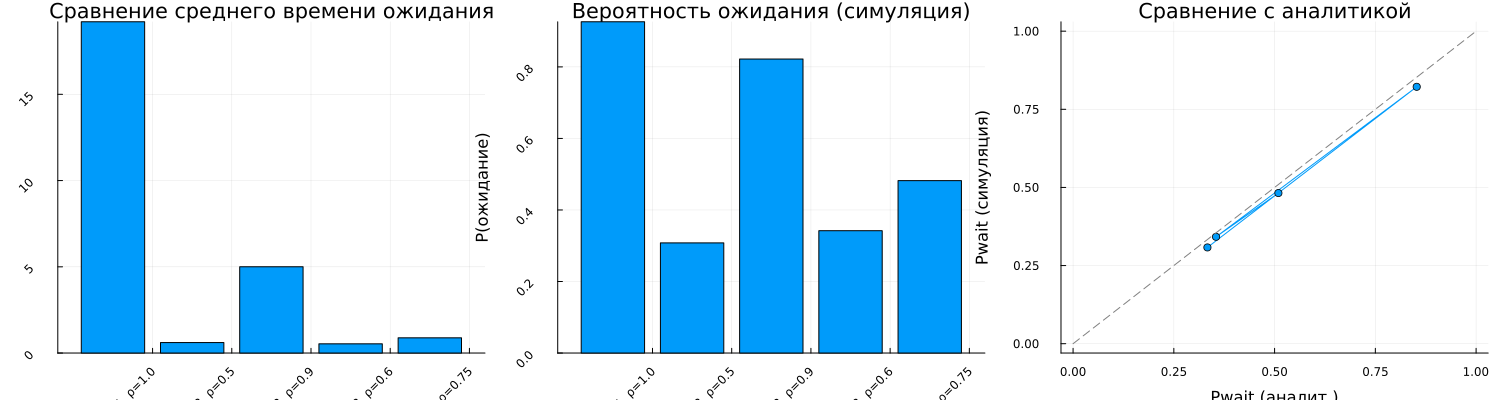

In [8]:
p1 = bar([r.label for r in results], [r.avg_wait for r in results], xlabel="Конфигурация", ylabel="Среднее время ожидания", title="Сравнение среднего времени ожидания", legend=false)
xticks!(p1, 1:length(results), [r.label for r in results], rotation=45)

p2 = bar([r.label for r in results], [r.Pwait_sim for r in results], xlabel="Конфигурация", ylabel="P(ожидание)", title="Вероятность ожидания (симуляция)", legend=false)
xticks!(p2, 1:length(results), [r.label for r in results], rotation=45)

p3 = plot([r.Pwait_anal for r in results], [r.Pwait_sim for r in results], xlabel="Pwait (аналит.)", ylabel="Pwait (симуляция)", title="Сравнение с аналитикой", marker=:circle, legend=false)
plot!([0,1], [0,1], lw=1, ls=:dash, color=:gray)

final_plot = plot(p1, p2, p3, layout=(1,3), size=(1500,400))
display(final_plot)
savefig(plotsdir("mmc_param_plots.png"))

println("\nРезультаты сохранены в data/ и plots/")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*